In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## U-Net++ Architecture
Implementing nested U-Net with dense skip connections and deep supervision.

In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_rate=0.15):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate)
        )
    
    def forward(self, x):
        return self.conv(x)

class UNetPP(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, filters=(32,64,128,256,512), dropout_rates=None):
        super().__init__()
        
        if dropout_rates is None:
            # Consistent dropout matching SegFormer (0.15)
            dropout_rates = {
                'encoder': [0.0, 0.0, 0.0, 0.0, 0.15],
                'decoder': [0.15, 0.15, 0.15, 0.15],
                'skip': 0.0,
                'final': 0.0
            }
        
        self.dropout_rates = dropout_rates
        f0, f1, f2, f3, f4 = filters
        
        # Encoder path (downsampling)
        self.conv0_0 = ConvBlock(in_ch, f0, dropout_rates['encoder'][0])
        self.conv1_0 = ConvBlock(f0, f1, dropout_rates['encoder'][1])
        self.conv2_0 = ConvBlock(f1, f2, dropout_rates['encoder'][2])
        self.conv3_0 = ConvBlock(f2, f3, dropout_rates['encoder'][3])
        self.conv4_0 = ConvBlock(f3, f4, dropout_rates['encoder'][4])
        
        self.pool = nn.MaxPool2d(2)
        
        # Nested decoder path
        self.conv0_1 = ConvBlock(f0+f1, f0, dropout_rates['decoder'][0])
        self.conv1_1 = ConvBlock(f1+f2, f1, dropout_rates['decoder'][1])
        self.conv2_1 = ConvBlock(f2+f3, f2, dropout_rates['decoder'][2])
        self.conv3_1 = ConvBlock(f3+f4, f3, dropout_rates['decoder'][3])
        
        self.conv0_2 = ConvBlock(f0*2+f1, f0, dropout_rates['decoder'][0])
        self.conv1_2 = ConvBlock(f1*2+f2, f1, dropout_rates['decoder'][1])
        self.conv2_2 = ConvBlock(f2*2+f3, f2, dropout_rates['decoder'][2])
        
        self.conv0_3 = ConvBlock(f0*3+f1, f0, dropout_rates['decoder'][0])
        self.conv1_3 = ConvBlock(f1*3+f2, f1, dropout_rates['decoder'][1])
        
        self.conv0_4 = ConvBlock(f0*4+f1, f0, dropout_rates['decoder'][0])
        
        # Upsampling
        self.up1 = nn.ConvTranspose2d(f1, f1, 2, stride=2)
        self.up2 = nn.ConvTranspose2d(f2, f2, 2, stride=2)
        self.up3 = nn.ConvTranspose2d(f3, f3, 2, stride=2)
        self.up4 = nn.ConvTranspose2d(f4, f4, 2, stride=2)
        
        # Final output
        self.final = nn.Conv2d(f0, out_ch, 1)
    
    def forward(self, x):
        # Encoder
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))
        
        # Nested skip connections - Level 1
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up1(x1_0)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up2(x2_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up3(x3_0)], 1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up4(x4_0)], 1))
        
        # Nested skip connections - Level 2
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up1(x1_1)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up2(x2_1)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up3(x3_1)], 1))
        
        # Nested skip connections - Level 3
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up1(x1_2)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up2(x2_2)], 1))
        
        # Nested skip connections - Level 4
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up1(x1_3)], 1))
        
        output = self.final(x0_4)
        return output

## Dataset and Data Loading

In [3]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

class SegDataset(Dataset):
    """Reads from a pre-made split folder that already contains 'img/' and 'mask/'
    subfolders (e.g. root_dir/train/Img, root_dir/train/Masks). Mask files are named
    '<stem>_mask.<ext>' (folder-name case is ignored)."""
    def __init__(self, root_dir, split='train', transform=None, img_size=(256, 256)):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.transform = transform

        split_dir = os.path.join(root_dir, split)
        # case-insensitive lookup so 'Img' / 'img' and 'Masks' / 'masks' all work
        def _sub(name):
            for d in os.listdir(split_dir):
                if d.lower() == name:
                    return os.path.join(split_dir, d)
            raise FileNotFoundError(f"'{name}' folder not found in {split_dir}: {os.listdir(split_dir)}")
        self.img_dir = _sub('img')
        self.mask_dir = _sub('masks')

        mask_stems = {os.path.splitext(f)[0].replace('_mask', ''): f
                      for f in os.listdir(self.mask_dir) if f.lower().endswith(IMG_EXTS)}

        self.pairs = []
        for f in sorted(os.listdir(self.img_dir)):
            if not f.lower().endswith(IMG_EXTS):
                continue
            stem = os.path.splitext(f)[0]
            if stem in mask_stems:
                self.pairs.append((f, mask_stems[stem]))

        assert len(self.pairs) > 0, f"No image/mask pairs found under {split_dir}"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]

        img = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
        label = Image.open(os.path.join(self.mask_dir, mask_name)).convert('L')

        img = img.resize(self.img_size)
        label = label.resize(self.img_size, Image.NEAREST)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = torch.from_numpy((np.array(label) > 0).astype(np.float32)).unsqueeze(0)

        return img, label


## Loss Functions and Metrics

In [4]:
def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    denom = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(logits, mask, bce_weight=0.6, dice_weight=0.4):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(logits, mask)
    probs = torch.sigmoid(logits)
    dice = DiceLoss()(probs, mask)
    return bce_weight * bce + dice_weight * dice

@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()
    
    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)
    
    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0,1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0,0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0,0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0
    
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc), "miou": float(miou)}

## Training and Validation Functions

In [5]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    train_acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, train_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = combined_loss(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        mets = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += mets[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    iou_background = tn / (tn + fp + fn + eps)
    iou_damage = tp / (tp + fp + fn + eps)
    miou = (iou_background + iou_damage) / 2
    
    epoch_loss = running_loss / len(loader.dataset)
    metrics = {"loss": epoch_loss, "iou": iou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc, "miou": miou,
               "confusion": np.array([[tn, fp], [fn, tp]])}
    return metrics

def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = optim.AdamW(
        [
            {"params": decay, "weight_decay": 1e-2},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )
    
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)
    
    train_losses = []
    val_losses = []
    val_ious = []
    val_dices = []
    train_accs = []
    val_accs = []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        
        val_metrics = validate(model, val_loader)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        train_accs.append(train_acc)
        val_accs.append(val_metrics['acc'])
        
        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'BSP_UNetPP.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")
        
        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    return train_losses, val_losses, val_ious, val_dices, train_accs, val_accs

## Training Configuration and Execution


In [6]:
def main():
    # Hyperparameters matching SegFormer
    BATCH_SIZE = 5
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 30
    PATIENCE = 3
    IMG_SIZE = (256, 256)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # folder that contains train/, val/, test/ — each with its own img/ and mask/ subfolders
    # (use 'train_augmented' if that's what you uploaded as your train split)
    root_dir = "/kaggle/input/datasets/huihuiiiiiiiii/bangaloresolarpanels-augmented/BangaloreSolarPanels_augmented"
    
    train_dataset = SegDataset(root_dir, split='train', transform=transform, img_size=IMG_SIZE)
    val_dataset = SegDataset(root_dir, split='val', transform=transform, img_size=IMG_SIZE)
    test_dataset = SegDataset(root_dir, split='test', transform=transform, img_size=IMG_SIZE)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # dropout as U-Net (new): encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15
    dropout_config = {
        'encoder': [0.0, 0.0, 0.0, 0.15, 0.2],
        'decoder': [0.15, 0.15, 0.15, 0.15],
    }
    FILTERS = (32, 64, 128, 256, 512)
    
    model = UNetPP(in_ch=3, out_ch=1, filters=FILTERS, dropout_rates=dropout_config).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    print("\nStarting U-Net++ training")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Weight Decay: 1e-3")
    print(f"Dropout: {dropout_config}")
    print(f"Threshold: 0.5")
    print(f"Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)\n")
    
    train_losses, val_losses, val_ious, val_dices, train_accs, val_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )
    
    return model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader

model, train_losses, val_losses, val_ious, val_dices, train_accs, val_accs, test_loader = main()

Training samples: 160
Validation samples: 10
Test samples: 13
Total parameters: 10,553,281

Starting U-Net++ training
Learning Rate: 0.0002
Weight Decay: 1e-3
Dropout: {'encoder': [0.0, 0.0, 0.0, 0.15, 0.2], 'decoder': [0.15, 0.15, 0.15, 0.15]}
Threshold: 0.5
Scheduler: ReduceLROnPlateau (factor=0.7, patience=7)


Epoch 1/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 14.87it/s]


Train Loss: 0.748102 | Train Acc: 0.7368
Val Loss: 0.640232 | Val Acc: 0.9759 | IoU: 0.5597 | Dice: 0.7177 | F1: 0.7177
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.640232

Epoch 2/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 18.98it/s]


Train Loss: 0.627310 | Train Acc: 0.9701
Val Loss: 0.574915 | Val Acc: 0.9815 | IoU: 0.5651 | Dice: 0.7221 | F1: 0.7221
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.574915

Epoch 3/30


...

Train Loss: 0.261998 | Train Acc: 0.9984
Val Loss: 0.256432 | Val Acc: 0.9898 | IoU: 0.7733 | Dice: 0.8722 | F1: 0.8722
Learning Rate: 2.00e-04

Epoch 29/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 18.05it/s]


Train Loss: 0.254108 | Train Acc: 0.9983
Val Loss: 0.244224 | Val Acc: 0.9897 | IoU: 0.7904 | Dice: 0.8830 | F1: 0.8830
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.244224

Epoch 30/30


Val batch: 100%|██████████| 5/5 [00:00<00:00, 17.97it/s]


Train Loss: 0.245614 | Train Acc: 0.9982
Val Loss: 0.227030 | Val Acc: 0.9891 | IoU: 0.7849 | Dice: 0.8795 | F1: 0.8795
Learning Rate: 2.00e-04
Saved best model with validation loss: 0.227030


## Visualization of Training Progress

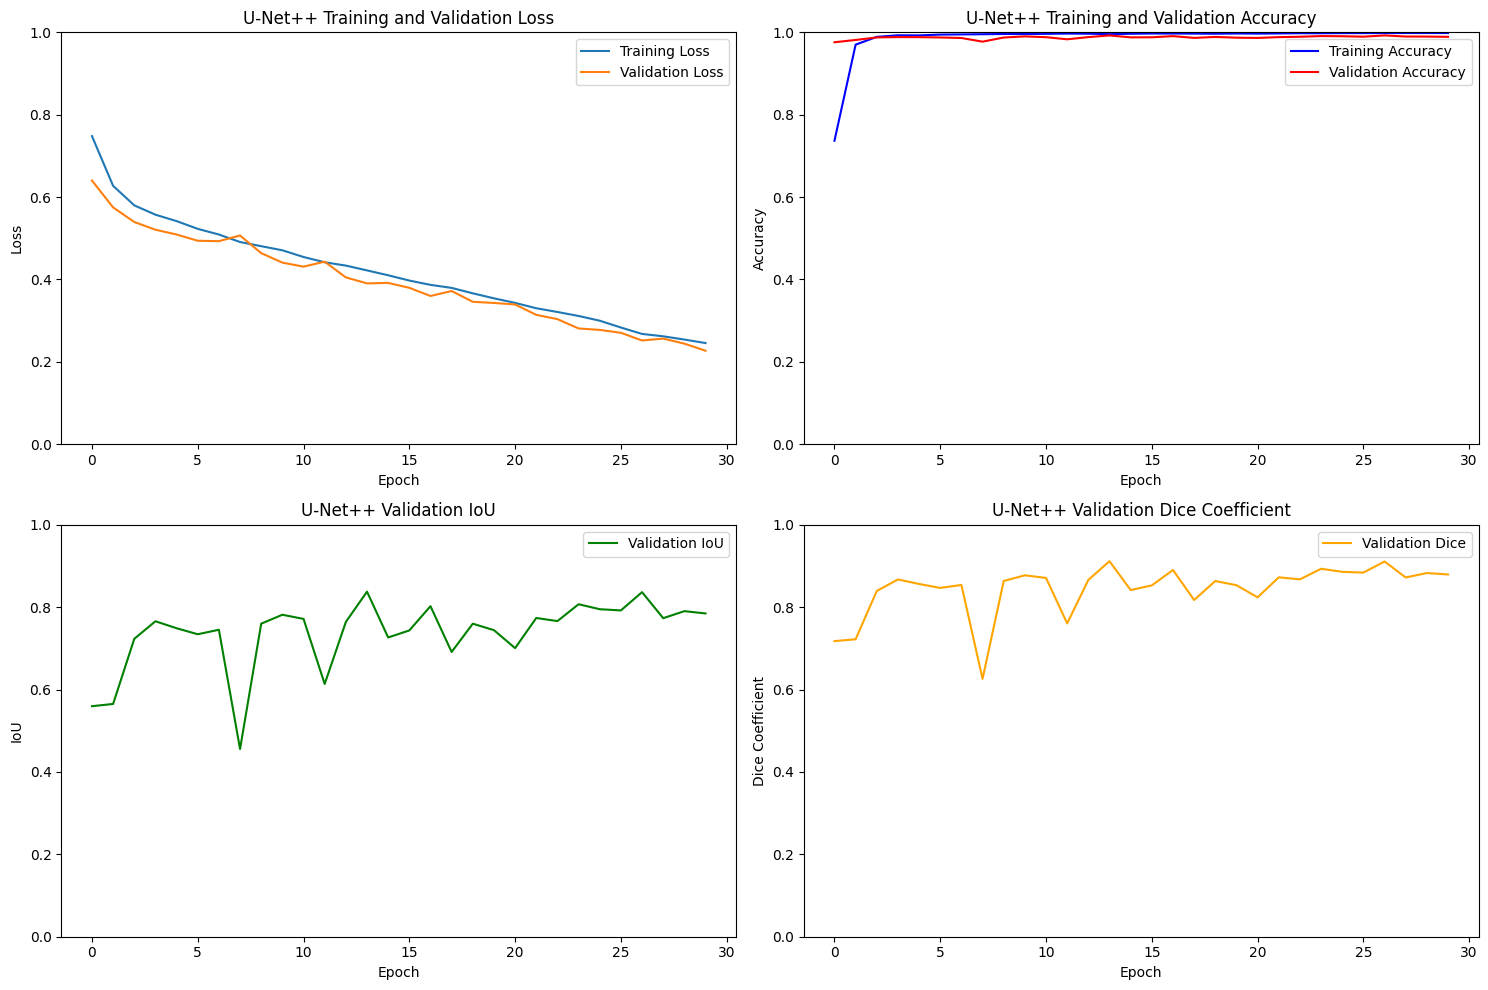

In [7]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.set_title('U-Net++ Training and Validation Loss')

ax2.plot(train_accs, label='Training Accuracy', color='blue')
ax2.plot(val_accs, label='Validation Accuracy', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.set_title('U-Net++ Training and Validation Accuracy')

ax3.plot(val_ious, label='Validation IoU', color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('IoU')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.set_title('U-Net++ Validation IoU')

ax4.plot(val_dices, label='Validation Dice', color='orange')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Dice Coefficient')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.set_title('U-Net++ Validation Dice Coefficient')

plt.tight_layout()
plt.savefig('BSP_UNetPP_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Test Evaluation

Loading best U-Net++ model for test evaluation...

Evaluating U-Net++ on test set...


Val batch: 100%|██████████| 13/13 [00:00<00:00, 25.09it/s]



U-NET++ TEST EVALUATION METRICS
Configuration: U-Net++ | dropout as U-Net (new): encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15
Test set processed with batch_size=1
Loss:            0.201109
IoU:             0.8882
mIoU:            0.9413
Dice Coefficient: 0.9408
Accuracy:        0.9946
Precision:       0.9087
Recall:          0.9752
F1-Score:        0.9408
Confusion matrix (pixel-level):
[[810982   3658]
 [   926  36402]]


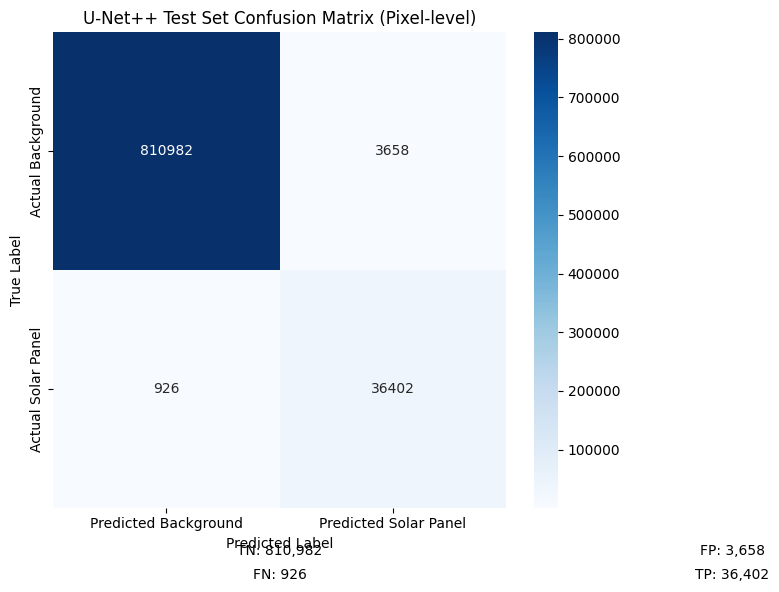

U-Net++ training and evaluation completed!


In [8]:
print("Loading best U-Net++ model for test evaluation...")
model.load_state_dict(torch.load('BSP_UNetPP.pth', map_location=device))
model.to(device)

print("\nEvaluating U-Net++ on test set...")
test_metrics = validate(model, test_loader)

print("\n" + "="*50)
print("U-NET++ TEST EVALUATION METRICS")
print("Configuration: U-Net++ | dropout as U-Net (new): encoder block 4 = 0.15, bottleneck = 0.2, decoder = 0.15")
print("="*50)
print(f"Test set processed with batch_size=1")
print(f"Loss:            {test_metrics['loss']:.6f}")
print(f"IoU:             {test_metrics['iou']:.4f}")
print(f"mIoU:            {test_metrics['miou']:.4f}")
print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
print(f"Accuracy:        {test_metrics['acc']:.4f}")
print(f"Precision:       {test_metrics['precision']:.4f}")
print(f"Recall:          {test_metrics['recall']:.4f}")
print(f"F1-Score:        {test_metrics['f1']:.4f}")
print("Confusion matrix (pixel-level):")
print(test_metrics["confusion"])
print("="*50)

plt.figure(figsize=(8, 6))
cm = test_metrics["confusion"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Background', 'Predicted Solar Panel'],
            yticklabels=['Actual Background', 'Actual Solar Panel'])
plt.title('U-Net++ Test Set Confusion Matrix (Pixel-level)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.text(0.5, -0.1, f'TN: {cm[0,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.1, f'FP: {cm[0,1]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(0.5, -0.15, f'FN: {cm[1,0]:,}', ha='center', transform=plt.gca().transAxes)
plt.text(1.5, -0.15, f'TP: {cm[1,1]:,}', ha='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('BSP_UNetPP_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("U-Net++ training and evaluation completed!")


## Test the model on images

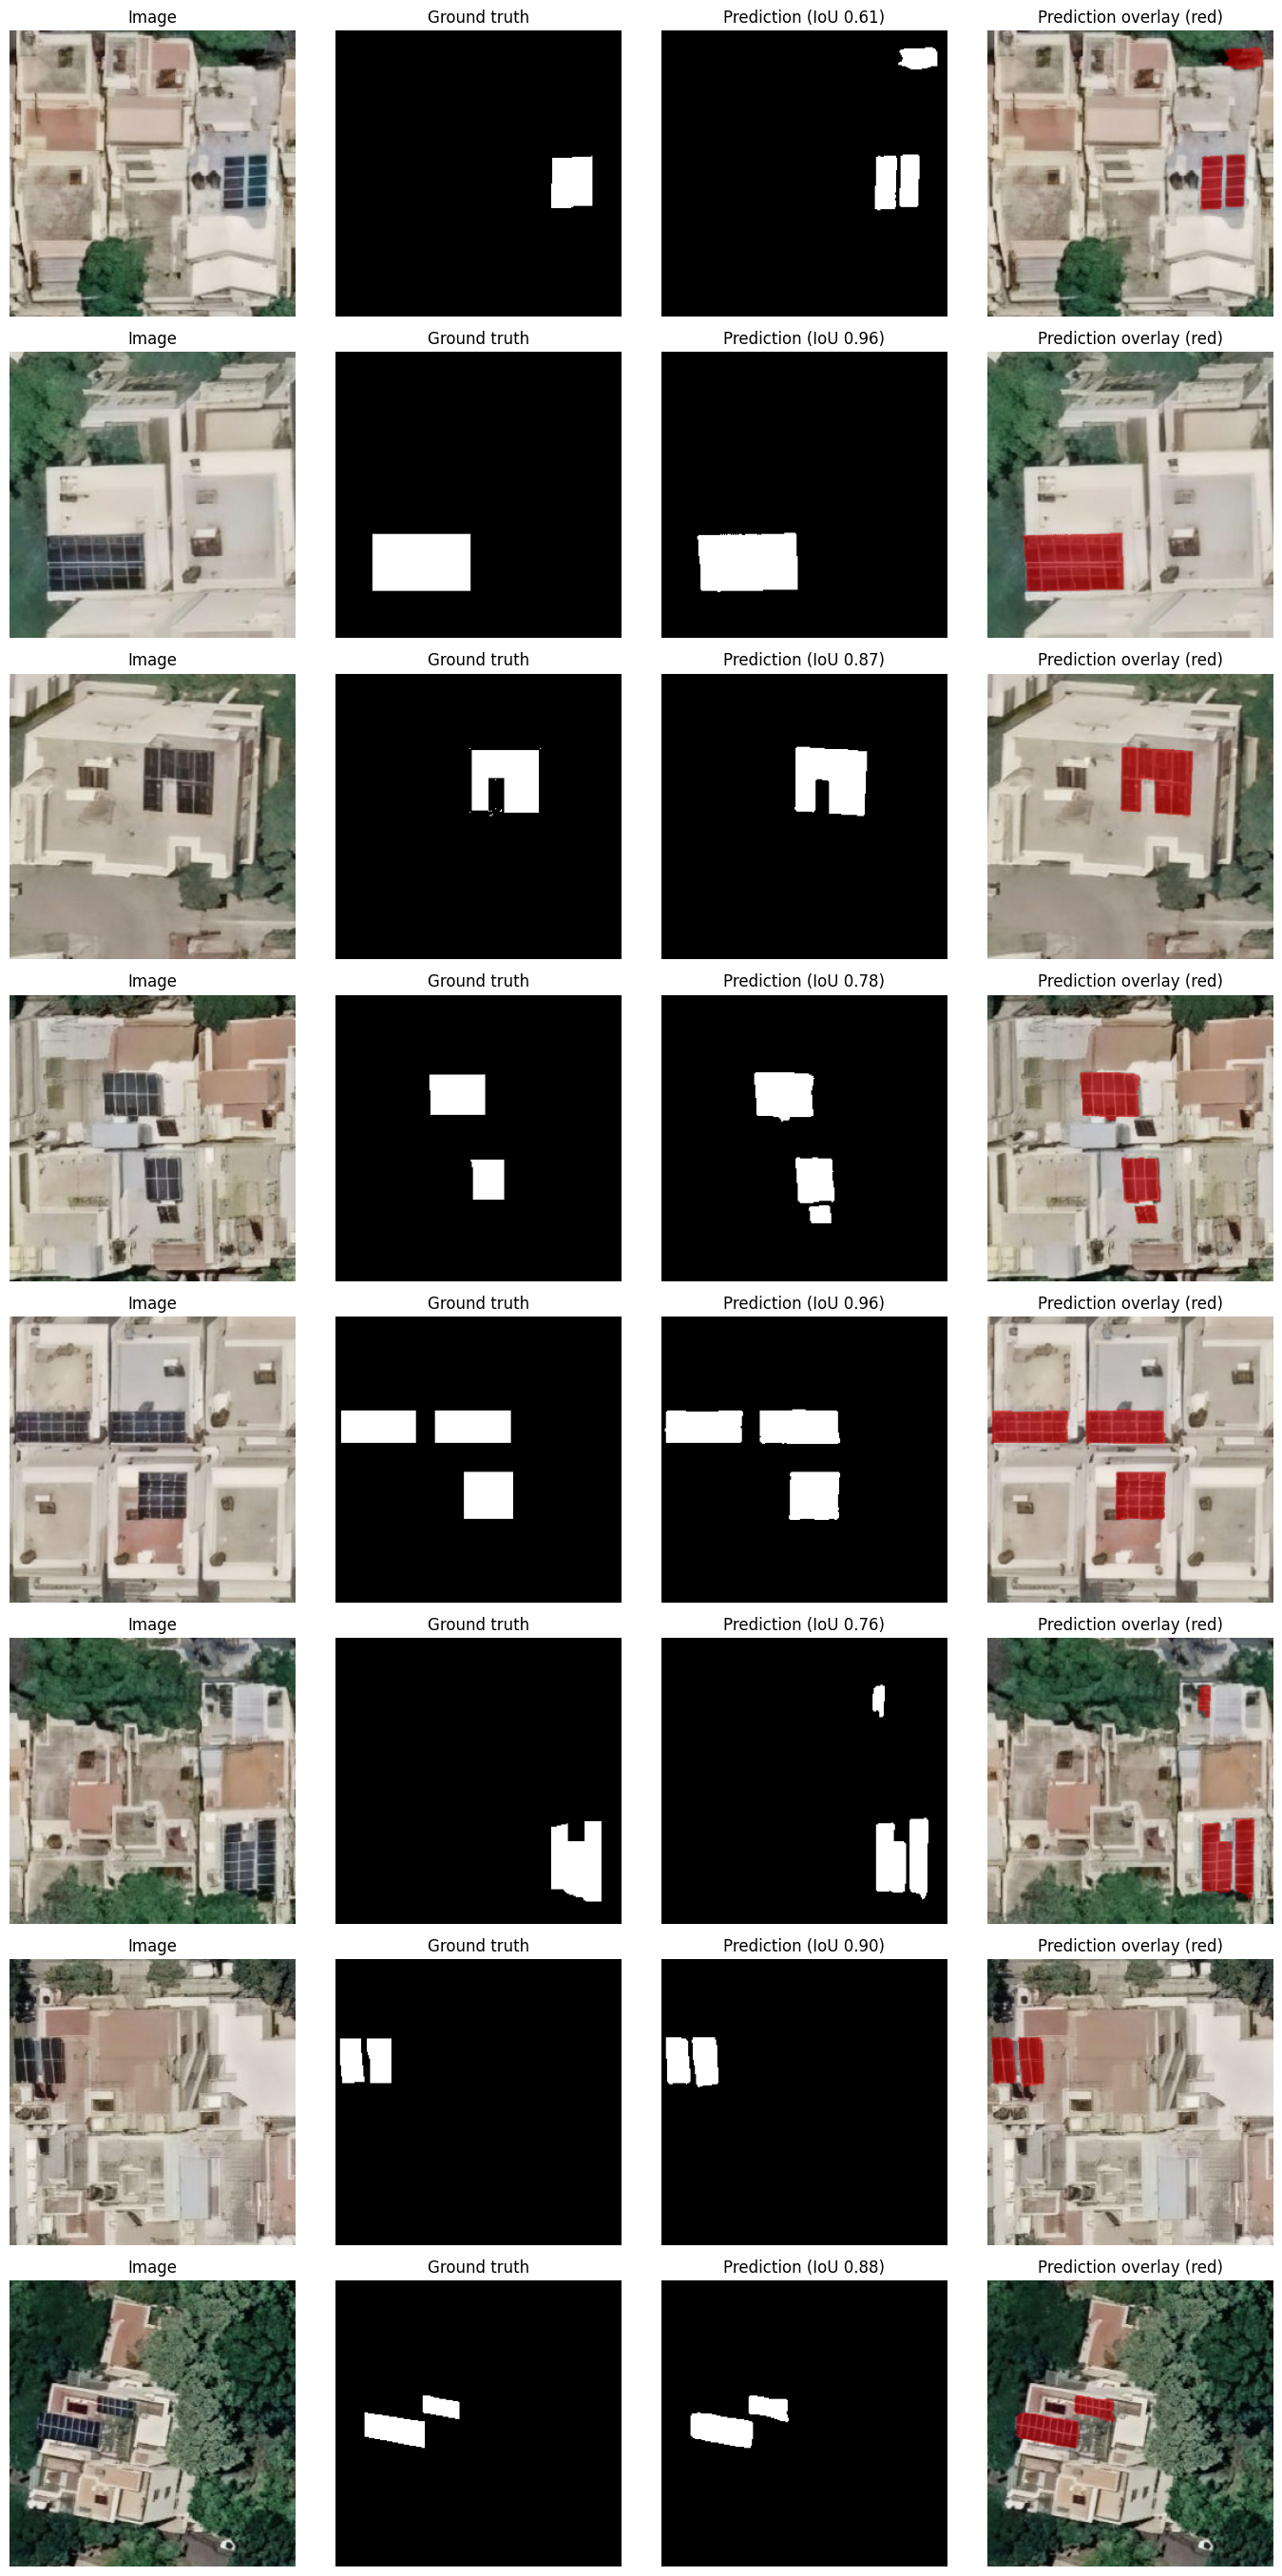

In [9]:
import random

root_dir = '/kaggle/input/datasets/huihuiiiiiiiii/bangaloresolarpanels-augmented/BangaloreSolarPanels_augmented'
IMG_SIZE = (256, 256)
FILTERS = (32, 64, 128, 256, 512)
DROPOUT = {'encoder': [0.0, 0.0, 0.0, 0.15, 0.2], 'decoder': [0.15, 0.15, 0.15, 0.15]}
CKPT = 'BSP_UNetPP.pth'

# rebuild the test set and load the best checkpoint
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_ds = SegDataset(root_dir, split='test', transform=tf, img_size=IMG_SIZE)

net = UNetPP(in_ch=3, out_ch=1, filters=FILTERS, dropout_rates=DROPOUT).to(device)
net.load_state_dict(torch.load(CKPT, map_location=device))
net.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_predictions(n=8, seed=0, thresh=0.5):
    random.seed(seed)
    idxs = random.sample(range(len(test_ds)), n)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    for r, i in enumerate(idxs):
        img, gt = test_ds[i]
        with torch.no_grad():
            prob = torch.sigmoid(net(img.unsqueeze(0).to(device)))[0, 0].cpu()
        pred = (prob >= thresh).float()

        rgb = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        gt_np, pred_np = gt[0].numpy(), pred.numpy()

        inter = (gt_np * pred_np).sum()
        union = gt_np.sum() + pred_np.sum() - inter
        iou = inter / union if union > 0 else float('nan')

        overlay = rgb.copy()
        overlay[pred_np > 0] = 0.5 * overlay[pred_np > 0] + 0.5 * np.array([1, 0, 0])

        axes[r, 0].imshow(rgb);                  axes[r, 0].set_title("Image")
        axes[r, 1].imshow(gt_np, cmap='gray');   axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(pred_np, cmap='gray'); axes[r, 2].set_title(f"Prediction (IoU {iou:.2f})")
        axes[r, 3].imshow(overlay);              axes[r, 3].set_title("Prediction overlay (red)")
        for a in axes[r]: a.axis('off')
    plt.tight_layout()
    plt.savefig('BSP_UNetPP_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()

show_predictions(n=8, seed=0)
